# Automated Language Detection System

**Authors:** Mohammed Ufraan, Faheem Ahmed, Shaik Mohd Abrar  

**Description:**  
This notebook implements a machine learning pipeline to identify languages based on character-level n-gram patterns, as detailed in our ML Assignment-3 report.

**Dataset:**
- **Name:** Language Detection Dataset  
- **Source:** Kaggle  
- **URL:** https://www.kaggle.com/datasets/basilb2s/language-detection  

In [13]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# load dataset (basil saji - kaggle)
df = pd.read_csv('dataset/language-detection.csv')

print(f"Total records: {len(df)}")
print(df['Language'].value_counts())
df.head()

Total records: 10337
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


## Data Preprocessing (Section III-B)
To improve model accuracy, we must remove "noise" identified in our paper:
1. **Lowercasing:** Standardizing character patterns.
2. **Special Characters:** Removing numbers and brackets (e.g., [1], [7]) common in Wikipedia data.

In [10]:
def clean_text(text):
    # removing citation brackets and numbers
    text = re.sub(r'\[.*?\]', '', text) 
    text = re.sub(r'\d+', '', text)
    # lowercasing and removing symbols
    text = text.lower()
    text = re.sub(r'[!@#$(),\n"%^*?\:;~`]', ' ', text)
    return text

# cleaning
df['cleaned_text'] = df['Text'].apply(clean_text)

## Model Training (Section IV-B)
We utilize a **Pipeline** that combines **TF-IDF Vectorization** (focusing on character bigrams and trigrams) with a **Multinomial Naive Bayes** classifier. This approach is computationally efficient for Industry 4.0 applications.

In [11]:
X = df['cleaned_text']
y = df['Language']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# implementation of parameters discussed in Section VI
model = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(2, 3), max_features=5000)),
    ('classifier', MultinomialNB())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## Results and Performance (Section V)
We evaluate the model using accuracy and a confusion matrix to identify overlaps between similar languages like Spanish and Portuguese.

Overall Accuracy: 98.07%


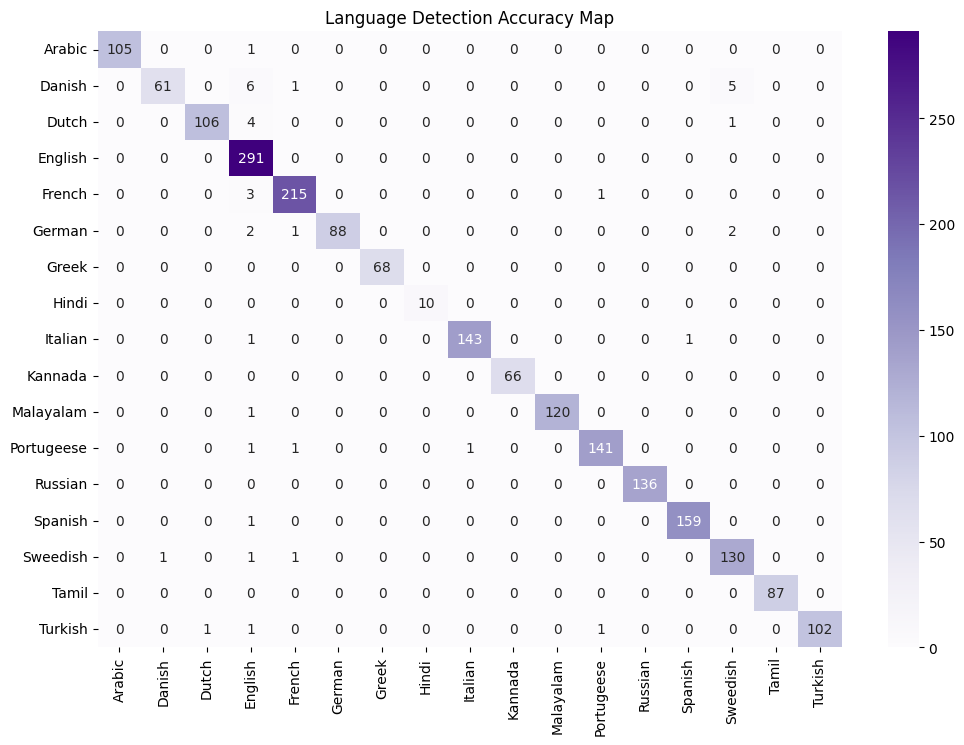

In [12]:
y_pred = model.predict(X_test)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")

# visualise confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            xticklabels=model.classes_, yticklabels=model.classes_, cmap='Purples')
plt.title('Language Detection Accuracy Map')
plt.show()

While Naive Bayes provides a fast and reliable baseline, current research in **Industry 4.0** highlights that algorithms like **Support Vector Machines (SVM)** can achieve higher precision (up to 97%) in specific industrial classification tasks.